Iris 분류 예측 모델

## SVM 주요 개념

#### Hyperplane (결정 경계)
: 데이터를 두 개 이상 클래스로 구분하는 경계선

#### Support vector
: 결졍경계와 가장 가까운 지점에 위치한 데이터 포인트 : svm은 이 포인트들만으로 결정 경계 학습 수행

#### Margin(여유 거리)
: 두 클래스 사이의 최소 거리 : 마진이 넓을수록 일반화 성능이 좋아짐


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC # SVM 분류 모델
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score  # 평가

데이터 가져오기

In [3]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [4]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
# 학습용/ 테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # 학습데이터 80%, 테스트 데이터 20%
)

In [7]:
# 스케일링(표준화)
# svm은 거리기반 알고리즘이기 때문에 스케일링 해줄 필요가 있음.

scaler = StandardScaler() # 표준화 객체 생성
X_train_scaled = scaler.fit_transform(X_train) # 학습데이터 기준으로 변환
X_test_scaled = scaler.transform(X_test) # 테스트 데이터 기준으로 변환

In [8]:
# svm 모델 생성 및 학습
svm_clf = SVC(kernel='rbf', C= 1.0, gamma= 'scale')

# kernel = rbf ---> 비선형 데이터에 적합한  RBF 커널 사용 / C : 오차 허용 범위 / gamma : 결정 경계의 유연성 (커질수록 복잡해짐)

svm_clf.fit(X_train_scaled, y_train) # 모델 학습 수행

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
## 예측 수행 (원래는 학습 결과를 저장하고, 저장된 결과파일을 서비스하는 추론 서버에 배포해줘야 함.
# 추론서버는 해당 파일을 기반으로 추론. 예측 수행.
y_pred = svm_clf.predict(X_test_scaled) # 테스트 데이터

In [10]:
## 평가 지표 출력
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred)) # matrix 행렬 출력

print("\nClassification Report")
print(classification_report(y_test, y_pred)) # precision, recall, acc등 출력


Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [11]:
## 예측결과 시각화
# 차원을 2개로 축소해서 분류 경계 시각화

from sklearn.decomposition import PCA
pca = PCA(n_components=2) # 2차원으로 축소

X_test_pca = pca.fit_transform(X_test_scaled)

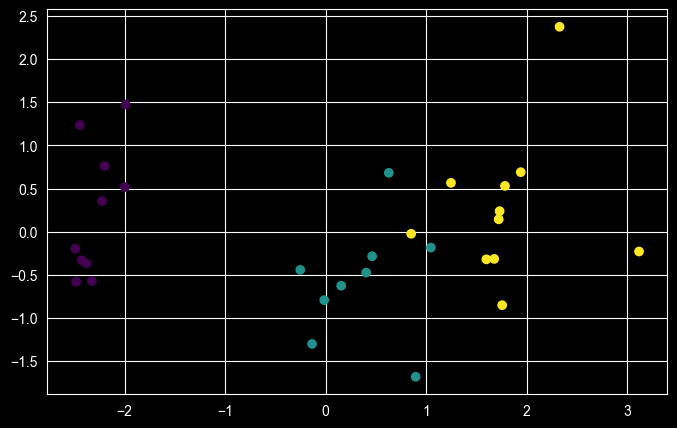

In [12]:
## 실제 값 vs 예측 값 비교 시각화
plt.figure(figsize=(8,5))
plt.scatter(
    X_test_pca[:,0], # PCA 1차원 축
    X_test_pca[:,1], # PCA 2차원 축
    c = y_pred,
    cmap='viridis',
    marker='o',
    label = 'Predicted'
)

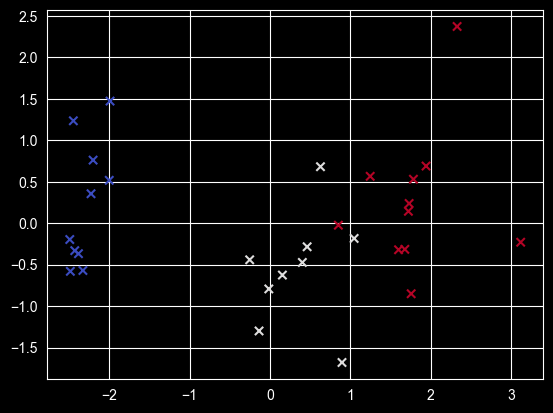

In [13]:
# 실제 라벨 위치를 점선으로 표시
plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c = y_test,
    cmap = 'coolwarm',
    marker='x',
    label = 'Actual'
)

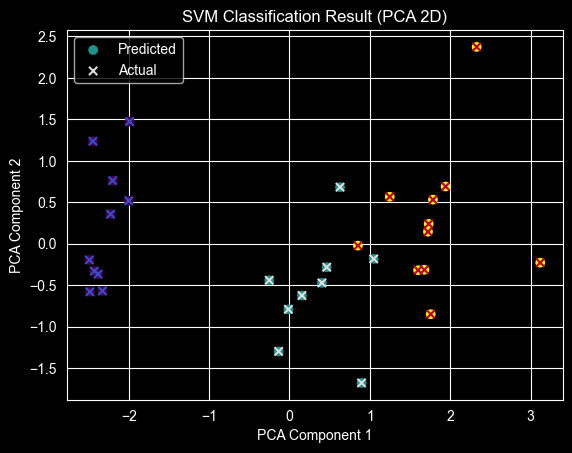

In [14]:
# 겹쳐서 봐 보자
plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c = y_pred,
    cmap = 'viridis',
    marker='o',
    label = 'Predicted'
)
plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c = y_test,
    cmap = 'coolwarm',
    marker='x',
    label = 'Actual'
)
plt.title("SVM Classification Result (PCA 2D)") # 그래프 제목
plt.xlabel("PCA Component 1")                   # x 축 이름
plt.ylabel("PCA Component 2")                   # y 축 이름
plt.legend() # 범례 표시
plt.grid(True) # 격자 추가
plt.show()

# Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
# 데이터 가져오기

iris = datasets.load_iris()
X = iris.data
y = iris.target #품종데이터

In [17]:
# 학습 / 테스트 데이터 분리

X_train, X_test, y_train , y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# random forest 모델 생성
rf_clf = RandomForestClassifier(
    n_estimators=100, # 생성할 결정트리 개수
    max_depth=None, # 트리 깊이를 제안하지 않겠다 -> 자동으로 최적 깊이 탐색
    random_state=42,
    n_jobs=-1 # 모든 cpu  코어를 사용해 학습 속도 향상
)

In [19]:
# 모델 학습 수행
rf_clf.fit(X_train, y_train) #학습 데이터 사용해 모델 학습

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


n_estimators 	100
criterion 	'gini'
max_depth 	None
min_samples_split 	2
min_samples_leaf 	1
min_weight_fraction_leaf 	0.0
max_features 	'sqrt'
max_leaf_nodes 	None
min_impurity_decrease 	0.0
bootstrap 	True
oob_score 	False
n_jobs 	-1
random_state 	42
verbose 	0
warm_start 	False
class_weight 	None
ccp_alpha 	0.0
max_samples 	None
monotonic_cst 	None

In [20]:
# 테스트 데이터 예측 수행
y_pred = rf_clf.predict(X_test)

In [21]:
# 평가 지표 출력
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [22]:
# PCA를 이용해 2차원으로 축소
# x 데이터 4개에서 2개로. 변수들 많을 때 다 쓰는 게 아니라 축소해서 사용
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)


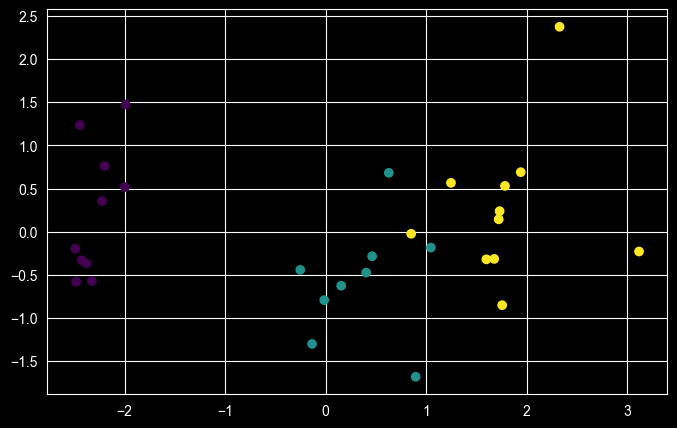

In [23]:
## 실제 값 vs 예측 값 비교 시각화
plt.figure(figsize=(8, 5))
plt.scatter(
    X_test_pca[:, 0],  # PCA 1차원 축
    X_test_pca[:, 1],  # PCA 2차원 축
    c=y_pred,
    cmap='viridis',
    marker='o',
    label='Predicted'
)

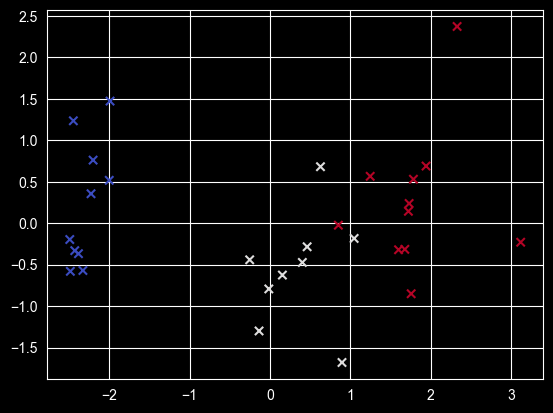

In [24]:
# 실제 라벨 위치를 점선으로 표시
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap='coolwarm',
    marker='x',
    label='Actual'
)

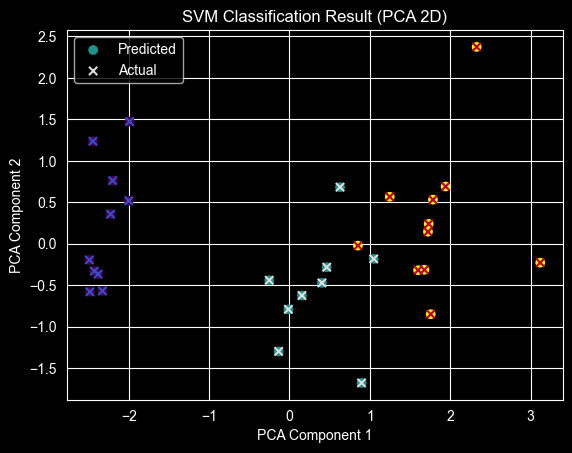

In [25]:
# 겹쳐서 봐 보자
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_pred,
    cmap='viridis',
    marker='o',
    label='Predicted'
)
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap='coolwarm',
    marker='x',
    label='Actual'
)
plt.title("SVM Classification Result (PCA 2D)")  # 그래프 제목
plt.xlabel("PCA Component 1")  # x 축 이름
plt.ylabel("PCA Component 2")  # y 축 이름
plt.legend()  # 범례 표시
plt.grid(True)  # 격자 추가
plt.show()

# XGBoost

xg boost 핵심 특징
1. Boosting
2.
3.
4.
5. Early Stopping


---

위스콘신 유방암 데이터.

---

요약하면

- mean 계열 : 종양 전체의 전반적 특징
- error 계열 : 값의 변동성 (안정적인지, 들쭉날쭉한지)
- worst 계열 : 가장 안 좋은 쪽 특성 (악성 판별에 특히 중요)

In [26]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [27]:
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [28]:
# 유방암 데이터셋 불러오기
dataset = load_breast_cancer()
X_features = dataset.data # 가져온 데이터셋에서 입력 변수(feature)
y_features = dataset.target # 정답 레이블 (타겟 : 악성 / 양성) label 변수에 저장

cancer_df = pd.DataFrame(data = X_features,columns=dataset.feature_names)
cancer_df['target'] = y_features

cancer_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [29]:
print(dataset.target_names) # 데이터셋이 어떤 레이블을 사용하는지 확인 ( malignant : 악성 (0), benign : 양성(1) )
print(cancer_df['target'].value_counts()) # 0과 1이 각각 몇 개 있는지 추렭해서 데이터 분포를 확인

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [30]:
X_features = cancer_df.iloc[: , :-1] # iloc = 자릿수 // loc = 컬럼 으로 접근
y_label = cancer_df.iloc[:, -1] #

In [31]:
X_features

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [32]:
y_label

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [33]:
# 전체 데이터에서 학습 80%, 테스트 20% 비율로 분리

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_label,
    test_size=0.2,
    random_state=42
)

# 전체 데이터에서 90%, 테스트 10% 비율로 분리하고 모델 튜닝시 활용
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state= 156
)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [34]:
# xgb가 계산을 최적화하기 위해 사용되는 DMatrix 구조로 학습 데이터를 반환

dtr = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

In [35]:
# 모델 학습에 필요한 하이퍼파라미터 설정

params = {
    'max_depth': 3, # 트리 깊이를 3개로 제한하여 과적합 방지
    'eta': 0.5, # learning rate를 설정하여 한 번의 학습 단계에서 조정되는 크기 설정
    'objective' : 'binary:logistic', # 이진 분류 문제이기 때문에 로지스틱 함수 사용해서 확률 예측
    'eval_metric' : 'logloss' # 평가 지표로서, 로그손실을 사용
}

num_rounds = 400 # 최대 boosting 반복 횟수

In [36]:
eval_list = [(dtr, 'train'), (dval, 'eval')]
xgb_model = xgb.train(
    params = params,
    dtrain= dtr,
    num_boost_round= num_rounds,
    early_stopping_rounds= 50, # 학습 결과가 좋으면 조기 종료
    evals = eval_list
)

[0]	train-logloss:0.33336	eval-logloss:0.38445
[1]	train-logloss:0.20678	eval-logloss:0.25634
[2]	train-logloss:0.14208	eval-logloss:0.18241
[3]	train-logloss:0.10238	eval-logloss:0.14806
[4]	train-logloss:0.07840	eval-logloss:0.11599
[5]	train-logloss:0.05891	eval-logloss:0.08452
[6]	train-logloss:0.04808	eval-logloss:0.07800
[7]	train-logloss:0.03824	eval-logloss:0.06836
[8]	train-logloss:0.03056	eval-logloss:0.05570
[9]	train-logloss:0.02509	eval-logloss:0.05089
[10]	train-logloss:0.02192	eval-logloss:0.04824
[11]	train-logloss:0.01939	eval-logloss:0.04399
[12]	train-logloss:0.01760	eval-logloss:0.03925
[13]	train-logloss:0.01566	eval-logloss:0.04145
[14]	train-logloss:0.01425	eval-logloss:0.04047
[15]	train-logloss:0.01344	eval-logloss:0.03989
[16]	train-logloss:0.01234	eval-logloss:0.03913
[17]	train-logloss:0.01168	eval-logloss:0.03600
[18]	train-logloss:0.01099	eval-logloss:0.03770
[19]	train-logloss:0.01042	eval-logloss:0.03740
[20]	train-logloss:0.00970	eval-logloss:0.03876
[2

In [37]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값 출력

pred_probs = xgb_model.predict(dtest)

# 예측한 확률값 중에서 처음 10개만 출력하여 예측 결과의 값을 확인
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시')
print(np.round(pred_probs[:10],3))

# 예측된 확률값이 0.5 보다 크면 양성(1), 아니면 악성(0)으로 판단
preds = [1 if x>0.5 else 0 for x in pred_probs]

print("예측값 10개만 표시 : ",  preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시
[0.99  0.    0.    1.    1.    0.    0.    0.344 0.129 1.   ]
예측값 10개만 표시 :  [1, 0, 0, 1, 1, 0, 0, 0, 0, 1]


In [38]:
# 행렬과 정확도 계산을 위한 지표를 가져옴
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [39]:
def get_clf_eval(y_test, pred = None, pred_prob = None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred) # precision & recall 조화 평균
    roc_auc = roc_auc_score(y_test, pred) # 측정 결과의 신뢰성을 보는 metric. 크게 쓰이는 게 아니긴 함.

    print('오차행렬')
    print(confusion)

    print("정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}, F1 : {3:.4f}, AUC : {4:.4f}".format(
        accuracy, precision, recall, f1, roc_auc
    ))

get_clf_eval(y_test, preds, pred_probs) # 위 성능 평가 함수를 호출해서 모델의 전체 성능을 확인

오차행렬
[[40  3]
 [ 2 69]]
정확도 : 0.9561, 정밀도 : 0.9583, 재현율 : 0.9718, F1 : 0.9650, AUC : 0.9510


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

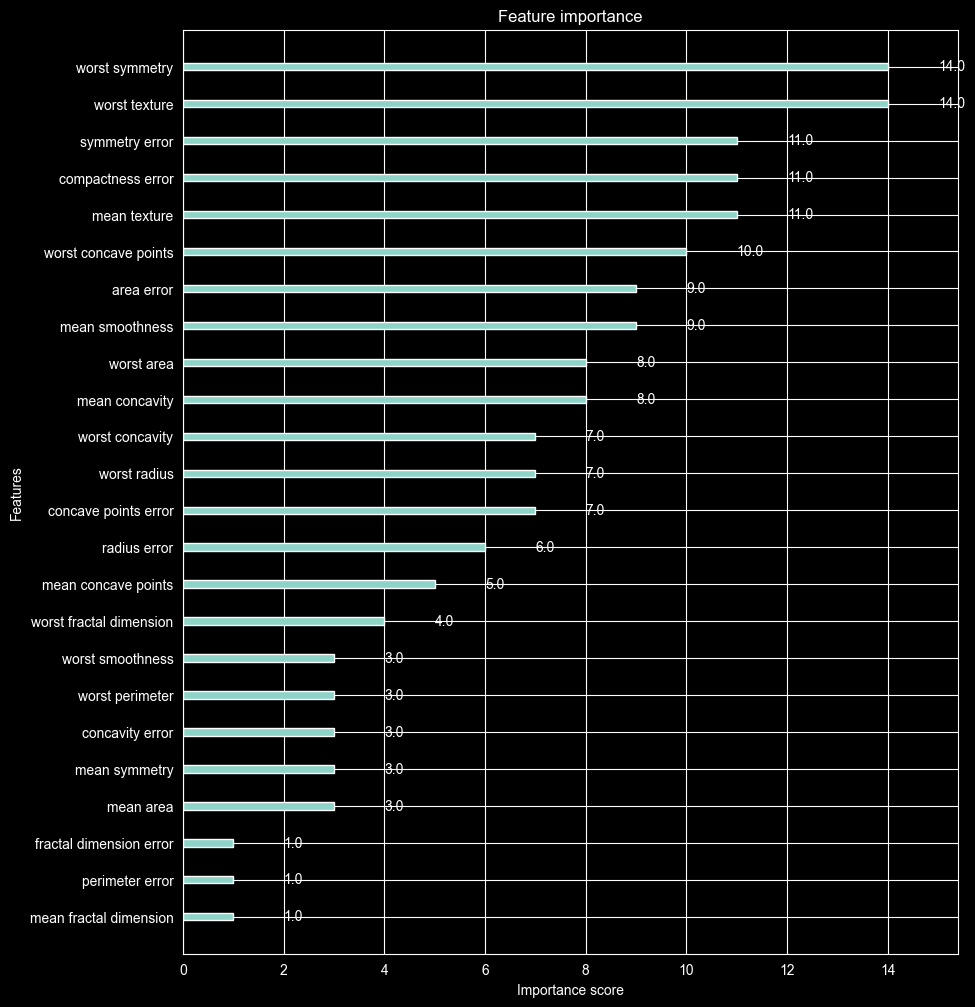

In [40]:
%matplotlib inline
fig, ax = plt.subplots(figsize = (10, 12))
# XGBoost 모델이 학습 중 어떤 feature를 많이 사용했는지 시각적으로 표현
# --> XGBoost가 학습하면서 양성/악성에 어떤 feature가 분류에 가장 기여했는지를 보여줌.

plot_importance(xgb_model, ax=ax)

In [41]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

In [42]:
import shap

In [43]:
shap.__version__

'0.49.1'

In [44]:
# 데이터 불러오기

housing = fetch_california_housing()

# 입력 변수(feature)
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# 타겟 변수(집값)
y = pd.Series(housing.target, name = 'target')

In [45]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [46]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: target, Length: 20640, dtype: float64

In [47]:
# 데이터 분할

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
# 모델 생성 및 학습

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000735 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [49]:
# SHAP Explainer 생성
# 모델마다 Explainer 가 조금식 다름.

explainer = shap.TreeExplainer(model)

# shap 값을 계산 (테스트 데이터 기준)
shap_values = explainer.shap_values(X_test) # 각 feature 가 예측에 얼마나 기여했는지 score 계산

In [50]:
X_test.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [53]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

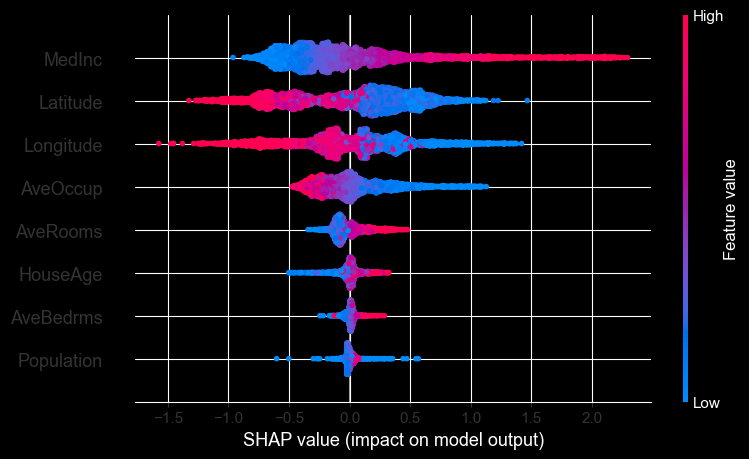

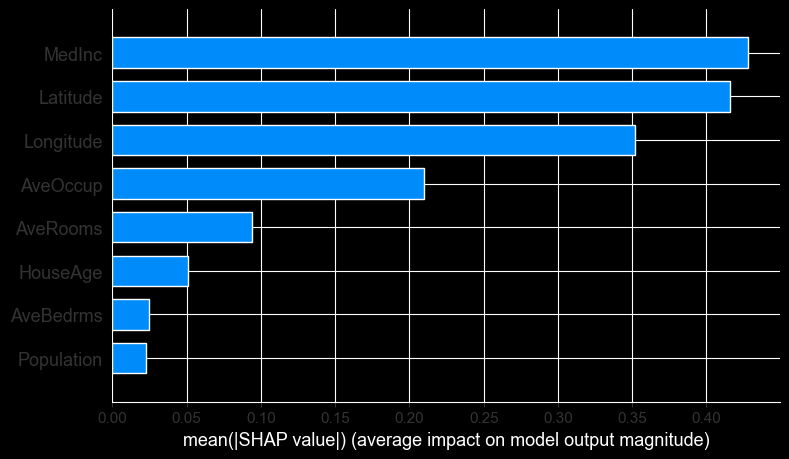

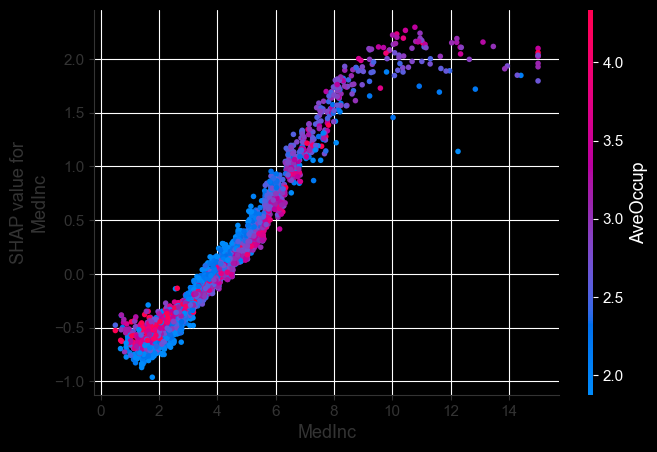

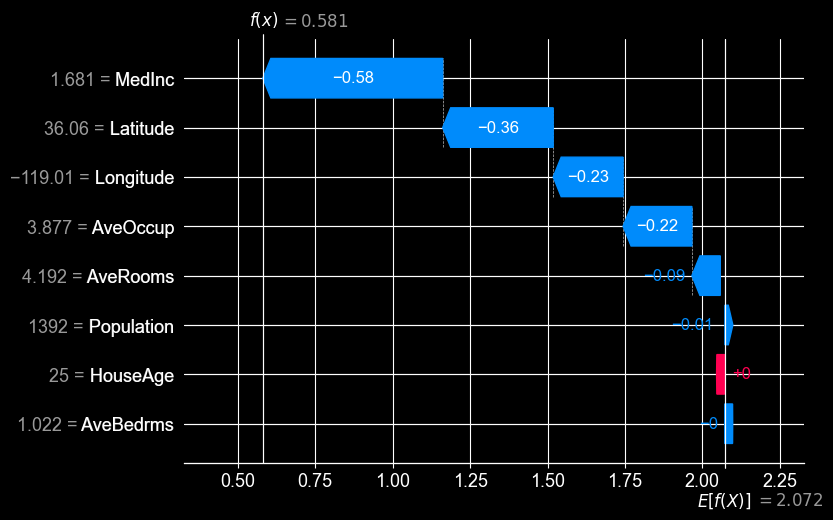


Shap 값 샘플
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0 -0.580755  0.000887 -0.091632  -0.000387   -0.014700 -0.222255 -0.356787   
1 -0.491580  0.025925 -0.105208   0.053759    0.006504  0.003098 -0.472470   
2  0.038094  0.309970 -0.044298   0.054821   -0.020946  0.784144  0.244839   
3  0.515880 -0.017496  0.030108  -0.010587    0.000954 -0.339485  0.149926   
4 -0.096139  0.029217 -0.024359   0.007217   -0.008561  0.077057 -0.035779   

   Longitude  
0  -0.225686  
1  -0.192753  
2   1.419950  
3   0.001678  
4   0.496815  


In [51]:
# 영항도 시각화
shap.summary_plot(shap_values, X_test) # 점 위치 : 영향 방향 (+/-), 색 : feature 값 크기

# shap bar plot (방향성)
shap.summary_plot(shap_values, X_test, plot_type="bar" )

# shap dependence plot
shap.dependence_plot("MedInc", shap_values, X_test)

# shap waterfall plot
sample_index = 0

# 개별 샘플 shap 값
shap.initjs()
shap.waterfall_plot(
    shap.Explanation(
        values = shap_values[sample_index],
        base_values= explainer.expected_value,
        data = X_test.iloc[sample_index],
        feature_names=X.columns
    )
)


# 그래프 볼 때 색깔 강조해줘서 예측 증가하면 빨강, 감소하면 파랑
# Force plot (interactive)
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

# shap 값 직접 확인
shap_df = pd.DataFrame(shap_values, columns=X.columns)

print("\nShap 값 샘플")
print(shap_df.head())

In [52]:
# 내일은 LIGHT GBM, XGBOOST 더 하면 될듯